In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import math
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams.update({'font.size': 22})

from sklearn.linear_model import LogisticRegression

In [3]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')
submission = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

# 1. How many variables are there with nan values?

## Nan in training data

In [4]:
print(train.isna().sum() / len(train) * 100, '\n')
print('-'*36, '\n')
print(train.isna().sum())

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64 

------------------------------------ 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In the training dataset; the 'Cabin' variable has 77% of its data - null. There are 177 and 2 null values in the 'Age' and the 'Embarked' variables

## Nan in testing data

In [5]:
print(test.isna().sum() / len(test) * 100, '\n')
print('-'*36, '\n')
print(test.isna().sum())

PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64 

------------------------------------ 

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


The fraction of missing data within the 'cabin' and the 'age' variables is certainly more than that of their training counterparts. Moreover, there is 1 missing value in the 'fare' variable also.

# 2. Dealing with the Nans

## Beginning with the cabin variable

In [6]:
print(train[train.Cabin.isna()].Survived.value_counts(), '\n')
print(train[train.Cabin.notna()].Survived.value_counts())

0    481
1    206
Name: Survived, dtype: int64 

1    136
0     68
Name: Survived, dtype: int64


It is evident that people whose cabin was known are more likely to survive than that of the people whose cabin was unknown. Therefore, I categorize the cabins in 2 categories - 'K' for known, and 'U' for unknown 

In [7]:
## for training

train.Cabin.fillna(0, inplace = True)
train['Cabin'] = train.Cabin.map(lambda x: 'U' if x == 0
                                               else 'K')

## for testing

test.Cabin.fillna(0, inplace = True)
test['Cabin'] = test.Cabin.map(lambda x: 'U' if x == 0
                                             else 'K')

In [8]:
print(train[train.Cabin == 'U'].Survived.value_counts(), '\n')
print('-'*36, '\n')
print(train[train.Cabin == 'K'].Survived.value_counts())

0    481
1    206
Name: Survived, dtype: int64 

------------------------------------ 

1    136
0     68
Name: Survived, dtype: int64


## The Embarked variable

In my opinion, surnames must make for real good predictor of the 'embarked' variable, as from a preson's surname, we can acknowledge their origin. This may award the highest probability of that person embarking/boarding from that place.

In [9]:
train['Surname'] = train.Name.map(lambda x: x.split(',')[0])

In [10]:
train[train.Embarked.isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,K,NaN,Icard
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,K,NaN,Stone


It is evident that the missing vaues in the 'Embarked' variable correspoind to passengers with surnames 'Icard' and 'Stone'. From Google, I found out that these surnames most commonly occur in France and Ireland, respectively. Therefore, it is wise to assign 'C' and 'S' in the corresponding rows of 'Embarked'. 

In [11]:
to_map = {'Icard': 'C',
          'Stone': 'S'}

train.Embarked.fillna(train.Surname.map(to_map),
                      inplace = True)

Now, for fun let's visualize the surnames that were most dead and most alive

<AxesSubplot:>

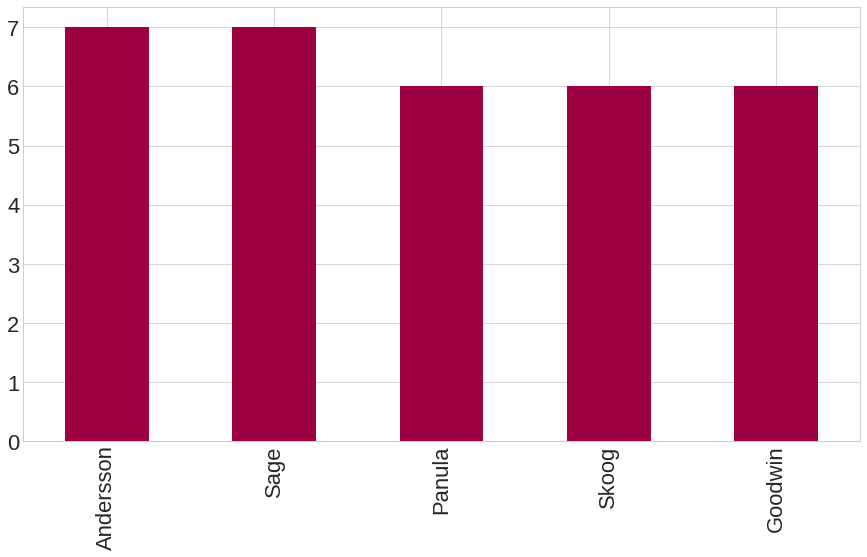

In [12]:
x = train[train.Survived == 0].Surname.value_counts(ascending = False)[:5]
x.plot(kind = 'bar', cmap = 'Spectral')

<AxesSubplot:>

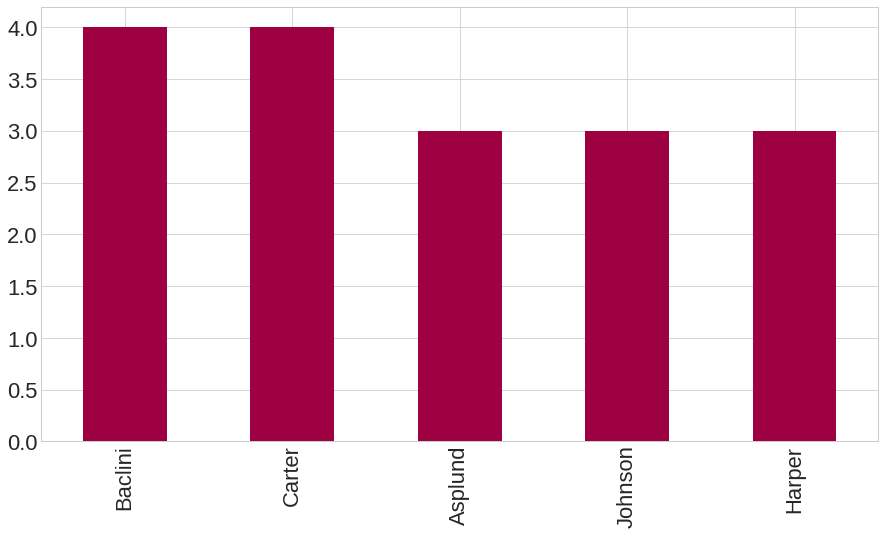

In [13]:
x = train[train.Survived == 1].Surname.value_counts(ascending = False)[:5]
x.plot(kind = 'bar', cmap = 'Spectral')

## The Age Variable

From the name of a passenger, if we know their title (Mr., Mrs., Master, Miss,...), we can quite well guess their age with a lot of credence. However, there's a constrain; let's say if a person is Master, we could certainly guess the range of age that the person must belong to (below 18), but we cannot predict the accurate age with a lot of precision. Therefore, I use the average age of the title that is missing to fill the null values in the 'Age' variable

In [14]:
train['Title'] = train.Name.map(lambda x: x.split(',')[1].split( )[0])
test['Title'] = test.Name.map(lambda x: x.split(',')[1].split( )[0])

In [15]:
print(train[train.Age.isna()].Title.value_counts(), '\n')
print('-'*36)
print(test[test.Age.isna()].Title.value_counts(), '\n')

Mr.        119
Miss.       36
Mrs.        17
Master.      4
Dr.          1
Name: Title, dtype: int64 

------------------------------------
Mr.        57
Miss.      14
Mrs.       10
Master.     4
Ms.         1
Name: Title, dtype: int64 



In [16]:
titles = ['Mr.', 'Miss.', 'Mrs.', 'Master.', 'Dr.', 'Ms.']

fill_val_train = {}
fill_val_test = {}

## for training

X = train.copy()
X.Age.fillna(0.0, inplace = True)

for title in titles:
    x = X[X.Title == title].Age.median()
    fill_val_train[title] = x
    
train.Age.fillna(train.Title.map(fill_val_train), inplace = True)

## for testing

X = test.copy()
X.Age.fillna(0.0, inplace = True)

for title in titles:
    x = X[X.Title == title].Age.median()
    fill_val_test[title] = x
    
test.Age.fillna(test.Title.map(fill_val_test), inplace = True)

In [17]:
print('Null values in Age(Train): ', train.Age.isna().sum())
print('Null values in Age(Test): ', test.Age.isna().sum())

Null values in Age(Train):  0
Null values in Age(Test):  0


## The Fare variable

In [18]:
test[test.Fare.isna()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,U,S,Mr.


The old man, aged just above 60 had Embarked from Southampton, and was lodged in 3rd passenger class. I use these details to predict the most probable fare that the passenger must have paid

In [19]:
X = test.copy()
X = X[X.Pclass == 3]
X = X[X.Embarked == 'S']
X = X[X.Age >= 18.0]
fare = X.Fare.median()

print('Most probable fare paid by the old man: ', fare)

test.fillna(fare, inplace = True)

Most probable fare paid by the old man:  8.05


In [20]:
print('Null values in Fare(Test): ', test.Fare.isna().sum())

Null values in Fare(Test):  0


## Let's see if there's some null values still remaining

In [21]:
print(test.isna().sum() / len(test) * 100, '\n')
print('-'*36, '\n')
print(test.isna().sum())

PassengerId    0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Cabin          0.0
Embarked       0.0
Title          0.0
dtype: float64 

------------------------------------ 

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Title          0
dtype: int64


Ho! we have successfully eliminated all null values both the training and testing dataset

# 3. Some more transformations

In [22]:
train['Age'] = train['Age'].map(lambda x: round(x))
train['Fare'] = train['Fare'].map(lambda x: round(x))

test['Age'] = test['Age'].map(lambda x: round(x))
test['Fare'] = test['Fare'].map(lambda x: round(x))

In [23]:
train['Family'] = train['SibSp'] + train['Parch']
test['Family'] = test['SibSp'] + test['Parch']

In [24]:
train['Sex'] = train['Sex'].map(lambda x: 1 if x == 'male'
                                            else 0)
test['Sex'] = test['Sex'].map(lambda x: 1 if x == 'male'
                                          else 0)

In [25]:
train['Cabin'] = train['Cabin'].map(lambda x: 1 if x == 'K'
                                            else 0)
test['Cabin'] = test['Cabin'].map(lambda x: 1 if x == 'K'
                                          else 0)

# Bucketizing variables

In [26]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,Family
0,1,0,3,"Braund, Mr. Owen Harris",1,22,1,0,A/5 21171,7,0,S,Braund,Mr.,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38,1,0,PC 17599,71,1,C,Cumings,Mrs.,1
2,3,1,3,"Heikkinen, Miss. Laina",0,26,0,0,STON/O2. 3101282,8,0,S,Heikkinen,Miss.,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35,1,0,113803,53,1,S,Futrelle,Mrs.,1
4,5,0,3,"Allen, Mr. William Henry",1,35,0,0,373450,8,0,S,Allen,Mr.,0


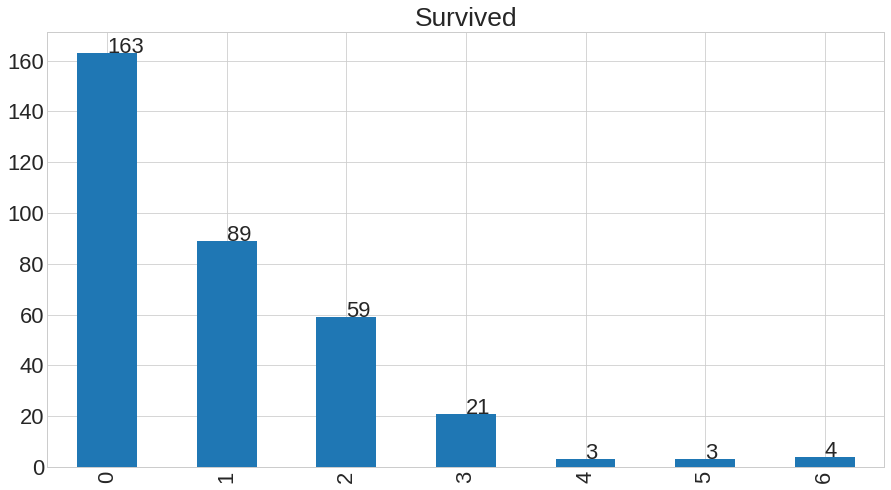

In [27]:
train[train.Survived == 1].Family.value_counts().sort_index().plot(kind = 'bar', title = 'Survived')

values = train[train.Survived == 1].Family.value_counts().sort_index().values

for num, value in enumerate(values):
    plt.annotate(value, 
                 (train[train.Survived == 1].Family.value_counts().sort_index().index[num], train[train.Survived == 1].Family.value_counts().sort_index().values[num]),)

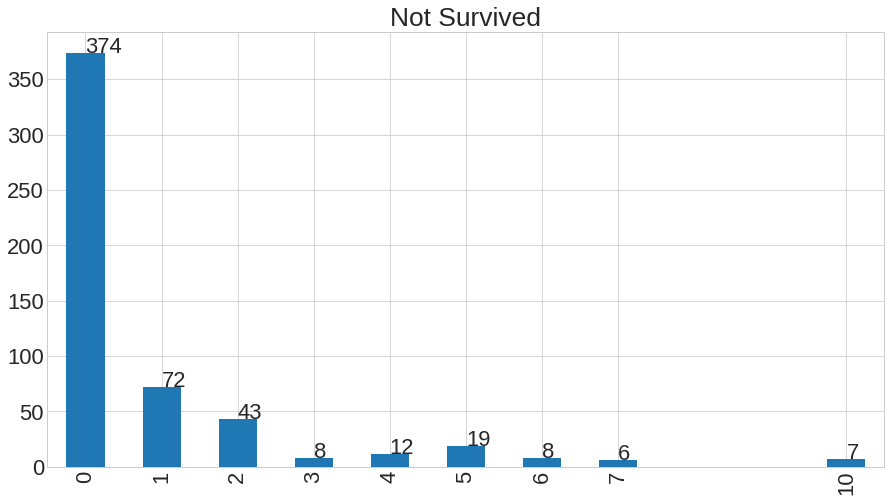

In [28]:
train[train.Survived == 0].Family.value_counts().sort_index().plot(kind = 'bar', title = 'Not Survived')

values = train[train.Survived == 0].Family.value_counts().sort_index().values

for num, value in enumerate(values):
    plt.annotate(value, 
                 (train[train.Survived == 0].Family.value_counts().sort_index().index[num], train[train.Survived == 0].Family.value_counts().sort_index().values[num]),)

In [29]:
family_bucket = {0: 0,
                 1: 1,
                 2: 1,
                 3: 1,
                 4: 0,
                 5: 0,
                 6: 0,
                 7: 0,
                 10: 0}

train['FamilyBucket'] = train['Family'].map(family_bucket)
test['FamilyBucket'] = test['Family'].map(family_bucket)

# CDFs of Numerical (continuous) variables

In [30]:
def EvalCdf(sample, x):
    count = 0
    for i in sample:
        if i <= x:
            count += 1
    return count / len(sample)

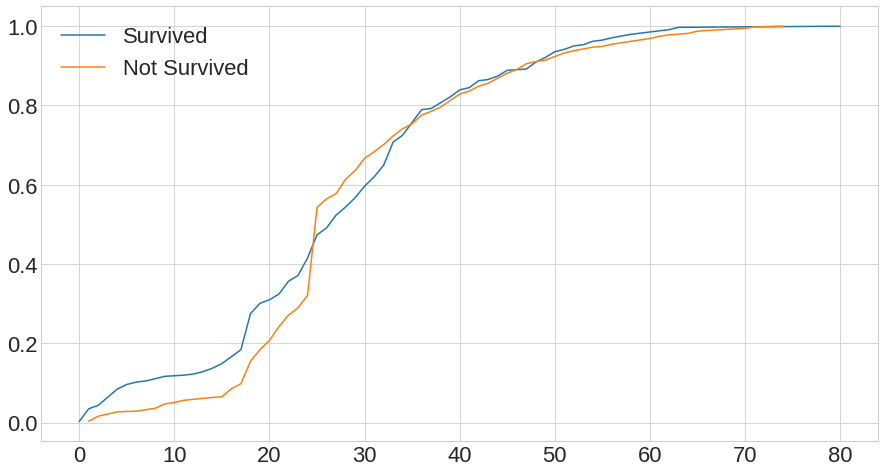

In [31]:
age_sur = train[train['Survived'] == 1].Age.values
age_notsur = train[train['Survived'] == 0].Age.values

age_sur.sort()
age_notsur.sort()

cdf_sur = [EvalCdf(age_sur, x) for x in age_sur]
cdf_notsur = [EvalCdf(age_notsur, x) for x in age_notsur]

plt.plot(age_sur, cdf_sur, label = 'Survived')
plt.plot(age_notsur, cdf_notsur, label = 'Not Survived')
plt.legend()

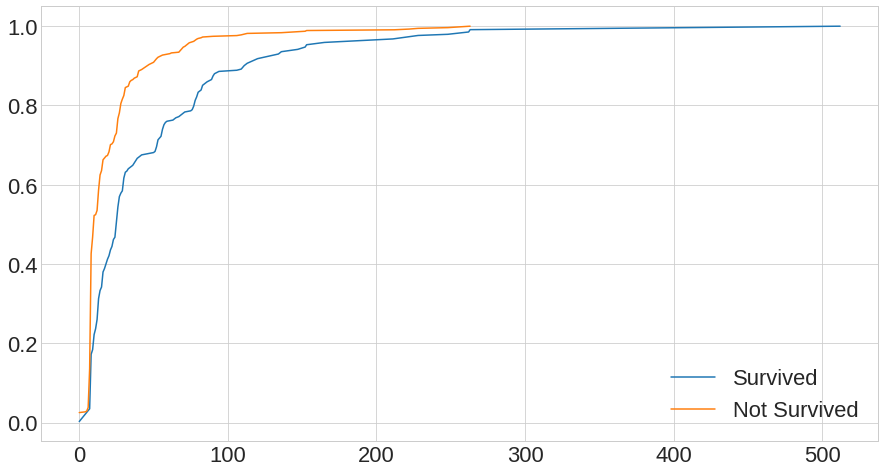

In [32]:
age_sur = train[train['Survived'] == 1].Fare.values
age_notsur = train[train['Survived'] == 0].Fare.values

age_sur.sort()
age_notsur.sort()

cdf_sur = [EvalCdf(age_sur, x) for x in age_sur]
cdf_notsur = [EvalCdf(age_notsur, x) for x in age_notsur]

plt.plot(age_sur, cdf_sur, label = 'Survived')
plt.plot(age_notsur, cdf_notsur, label = 'Not Survived')
plt.legend()

In [33]:
print(train.Age.min(), ',', train.Age.max())
print(test.Age.min(), ',', test.Age.max())

0 , 80
0 , 76


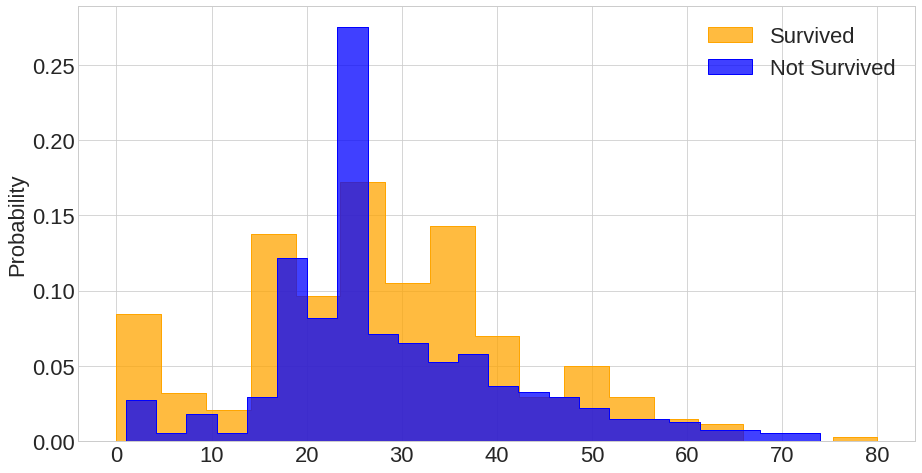

In [34]:
age_sur = list(train[train.Survived == 1].Age.values)
age_not_sur = list(train[train.Survived == 0].Age.values)

sns.histplot(age_sur, stat = 'probability', element = 'step', color = 'orange', label = 'Survived')
sns.histplot(age_not_sur, stat = 'probability', element = 'step', color = 'blue', label = 'Not Survived')
plt.legend()

<BarContainer object of 81 artists>

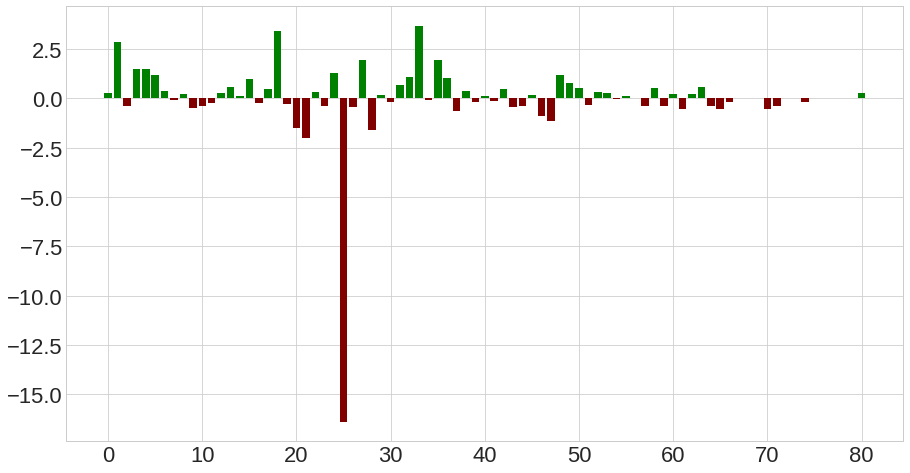

In [35]:
c_sur = Counter(age_sur)
n_sur = len(age_sur)

c_not_sur = Counter(age_not_sur)
n_not_sur = len(age_not_sur)

rng = np.arange(max(age_sur) + 1)
diffs = []

for item, count in c_sur.items():
    c_sur[item] /= n_sur
    
for item, count in c_not_sur.items():
    c_not_sur[item] /= n_not_sur
    
for i in rng:
    diff = c_sur[i] - c_not_sur[i]
    diffs.append(diff*100)
    
plt.bar(rng, diffs, color = pd.Series(diffs).map(lambda x: 'green' if x>=0
                                                else 'maroon'))

In [36]:
to_map = {}

for age, diff in zip(rng, diffs):
    if diff < 0:
        to_map[age] = 0
    else:
        to_map[age] = 1
        
train['Age'] = train['Age'].map(to_map)
test['Age'] = test['Age'].map(to_map)

In [37]:
train.Age.value_counts()

1    448
0    443
Name: Age, dtype: int64

In [38]:
test.Age.value_counts()

1    210
0    208
Name: Age, dtype: int64

In [39]:
train.isna().sum()

PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age             0
SibSp           0
Parch           0
Ticket          0
Fare            0
Cabin           0
Embarked        0
Surname         0
Title           0
Family          0
FamilyBucket    0
dtype: int64

# 4. Apply ML

Let's not get into the explorations in this part... Let's make predictions and see how good our model is... 

In [40]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,Family,FamilyBucket
0,1,0,3,"Braund, Mr. Owen Harris",1,1,1,0,A/5 21171,7,0,S,Braund,Mr.,1,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,1,1,0,PC 17599,71,1,C,Cumings,Mrs.,1,1
2,3,1,3,"Heikkinen, Miss. Laina",0,0,0,0,STON/O2. 3101282,8,0,S,Heikkinen,Miss.,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,1,1,0,113803,53,1,S,Futrelle,Mrs.,1,1
4,5,0,3,"Allen, Mr. William Henry",1,1,0,0,373450,8,0,S,Allen,Mr.,0,0


In [41]:
features = ['Pclass', 'Sex', 'Cabin', 'FamilyBucket', 'Age']

X = train[features].copy()
y = train['Survived'].copy()

In [42]:
##lr = LogisticRegression(random_state = 0).fit(X, y)

##predictions = lr.predict(test[features])
##print(lr.score(X, y))

In [43]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=2)
model.fit(X, y)
predictions = model.predict(test[features])
print(model.score(X, y))

0.8114478114478114


In [44]:
len(predictions)

418

In [45]:
submission['Survived'] = predictions
submission.to_csv('submission.csv', index = False)